<a href="https://colab.research.google.com/github/fabiospiazzi/MiniProjeto_II_SCTec/blob/main/MiniProjeto_2_SCTEC_F%C3%A1bio_R_Spiazzi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mini-Projeto 2

##Construir, treinar, validar, comparar e estressar um Pipeline Preditivo Multiclasse ponta a ponta capaz de classifi car dígitos manuscritos a partir do dataset MNIST (mnist_784).

Autor: Fábio Rodrigues Spiazzi

# Fase 1. Carregamento e Pré-processamento

## 1.1  Importar o dataset MNIST via scikit-learn ( fetch_openml('mnist_784') ) ou via tensorfl ow.keras.datasets.mnist .

In [ ]:
from sklearn.datasets import fetch_openml

print ( "Baixando o dataset MNIST..." )
mnist = fetch_openml( 'mnist_784' , version= 1 , as_frame=False, parser= 'auto' )
print ( "Finalizou o processo de baixar o dataset MNIST!" )

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!


## 1.2 Exibir a dimensionalidade das matrizes (X e y) e comprovar a distribuição das classes (balanceamento de dígitos de 0 a 9).

In [ ]:
# Separando Entradas (X) e Rótulos (y)
X, y = mnist.data, mnist.target

In [ ]:
# Exibe a dimensionalidade das matrizes

print(f'Tamanho de X (quantidade de figuras: {X.shape[0]} e dimensão: {X.shape[1]})')
print('Tamanho de y: ', y.shape)

Tamanho de X (quantidade de figuras: 70000 e dimensão: 784)
Tamanho de y:  (70000,)


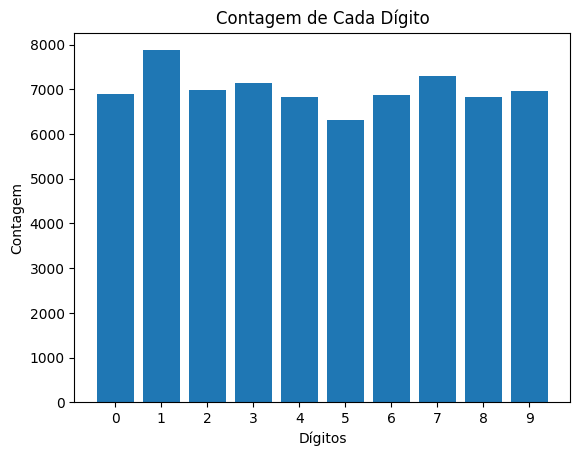

In [ ]:
# Gráfico da contagem dos dígitos
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y, return_counts=True)
plt.bar(unique, counts)
plt.xlabel('Dígitos')
plt.ylabel('Contagem')
plt.title('Contagem de Cada Dígito')
plt.show()

In [ ]:
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [ ]:
y

array(['5', '0', '4', ..., '4', '5', '6'], dtype=object)

## 1.3 Gerar uma grade visual de no mínimo 2 x 5 com matplotlib , exibindo exemplos de imagens de cada dígito junto com seus respectivos rótulos originais.

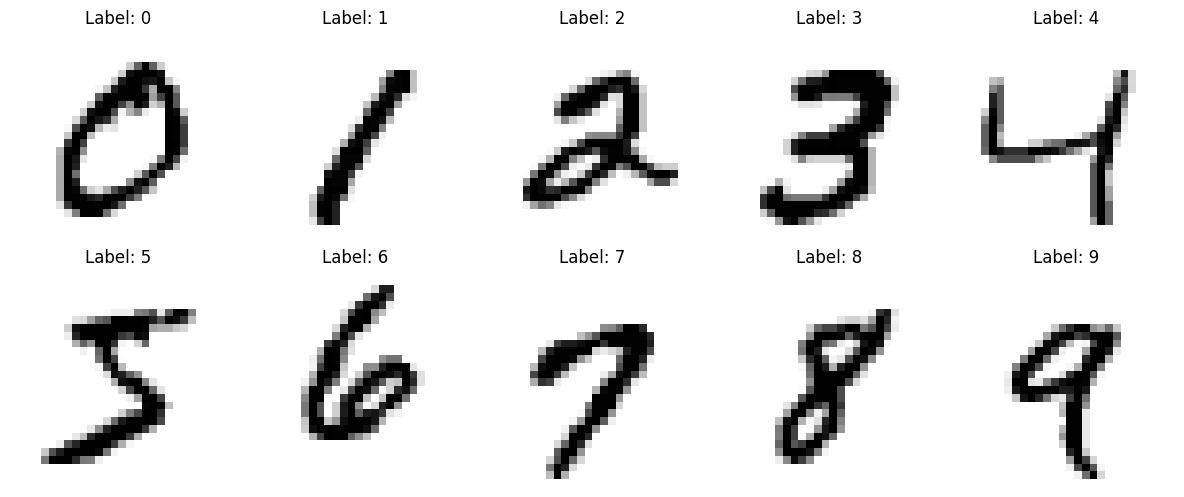

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Separa os dígitos em valores únicos
unique_digits = np.unique(y)

# Cria a grade de visualização 2x4
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten() # Achata a matriz dos eixo para facilitar a iteração

for i, digit in enumerate(unique_digits):
    # Encontra o índice para o digito corrente do for
    idx = np.where(y == digit)[0][0]

    # Busca a imagem do índice acima e reamostra pra 28x28
    image = X[idx].reshape(28, 28)

    # Mostra as imagens
    axes[i].imshow(image, cmap='binary')
    axes[i].set_title(f'Label: {y[idx]}')
    axes[i].axis('off') # Esconde ticks do gráfico

plt.tight_layout() # Ajusta o layout pra não sobrepor as imagens
plt.show()

## 1.4 Explicações sobre a estrutura de dados:

A escala de intensidade de pixel de 0 a 255 representa a resolução radiométrica da imagem, comumente chamada de intensidade em escala de cinza quando há apenas um canal (imagem monocromática/pancromática). Trata-se de uma imagem de 8 bits, pois cada pixel é armazenado em 1 byte (8 bits). Como cada bit pode ter 2 estados ($0$ ou $1$), temos $2^8 = 256$ tonalidades possíveis — em que 0 é o preto puro, 255 é o branco puro e os valores intermediários são as gradações de cinza.

Em termos de resolução espacial, uma imagem bidimensional de 28 pixels de largura por 28 pixels de altura possui um total de $28 \times 28 = 784$ pixels. Para o processamento em modelos de aprendizado de máquina, essa matriz bidimensional é achatada (flattening), sendo representada vetorialmente como um vetor unidimensional de 784 características (features).

# Fase 2. Pipeline de Pré-processamento e Divisão dos Dados

### 2.1 Divisão Estratificada: Dividir a base em Treino, Validação e Teste (ex: 70% treino, 10% validação e 20% teste ou 80% treino/validação e 20% teste), garantindo estratificação por classe ( stratify=y ).

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 2.2 Normalização / Escalonamento: Aplicar o redimensionamento dos pixels para a escala [0.0, 1.0] (dividindo por 255.0 ou via MinMaxScaler/StandardScaler).

In [ ]:
# Normalização divindo por 255
X_train = X_train / 255.0
X_test = X_test / 255.0

# Normalização via MinMaxScaler
# from sklearn.preprocessing import MinMaxScaler
# scaler = MinMaxScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)

# Normalização usando StandardScaler
# from sklearn.preprocessing import StandardScaler
# scaler = StandardScaler()
# X_train = scaler.fit_transform(X_train)
# X_test = scaler.transform(X_test)
#

### 2.3 Justificar textualmente a importância da normalização para a convergência de modelos lineares e distâncias métricas.

Os dados normalizados aprimoram o desempenho e melhoram a precisão de um modelo. Ele ajuda os algoritmos que dependem de métricas de distância, como os vizinhos mais próximos ou as máquinas de vetor de suporte, evitando que os recursos com escalas maiores dominem o processo de aprendizado.

**1. Modelos Lineares e a Convergência do Gradiente**

Em modelos lineares (como a Regressão Logística) treinados via Gradiente Descendente, o objetivo é encontrar os pesos ideais minimizando uma função de custo.

**O problema sem normalização:** Em imagens de dígitos, pixels de fundo costumam ser completamente pretos (0), enquanto pixels do traço do dígito variam de cinza a branco (1)Se os dados não forem normalizados, os recursos (pixels) terão escalas muito diferentes. Isso deforma a função de custo, tornando-a uma elipse excessivamente alongada (como uma "vala" estreita). O gradiente começa a oscilar violentamente de um lado para o outro, exigindo uma taxa de aprendizado muito pequena e centenas de épocas a mais para convergir.

**O efeito da normalização**: Ao reescalar os pixels para o intervalo \([0, 1]\) (subtraindo a média e dividindo pelo desvio padrão), a superfície da função de custo torna-se esférica e simétrica. O gradiente aponta diretamente para o mínimo global. Isso permite taxas de aprendizado maiores e uma convergência drasticamente mais rápida.

**2. Distâncias Métricas (KNN, K-Means)**

Algoritmos que dependem do cálculo de distâncias (como a Distância Euclidiana) medem a similaridade geométrica entre duas imagens vetorizadas.

**O problema sem normalização:** Se uma determinada região da imagem contiver variações de valores muito altas (ex: pixels centrais variando de \(0\) e outra região contiver variações baixas (ex: bordas variando de \(0\) os pixels de alta intensidade dominarão completamente o cálculo da distância. O algoritmo assumirá erroneamente que pequenas mudanças nos pixels centrais importam muito mais do que formas desenhadas nas bordas.

**O efeito da normalização:** Ao colocar todos os pixels na mesma escala, garante-se que cada pixel tenha o mesmo peso inicial na decisão do modelo. A distância matemática passará a refletir a real diferença estrutural do dígito desenhado, e não a intensidade bruta de pontos isolados.

# Fase 3. Implementação e Treinamento dos 3 Modelos

## 3.1 Grids de Busca

### 3.1.1 Grids de Busca - Modelos: Random Forest



In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

# Teste Grade 1
# Grid ajustado para melhor desempenho no MNIST
melhores_parametros_rf = {
    'n_estimators': [100, 200],
    'max_depth': [15, 25, None],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

# Configuração do GridSearch
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=melhores_parametros_rf,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Execução e cronometragem com perf_counter
tempo_inicial = time.perf_counter()

grid_search_rf.fit(X_train, y_train)

tempo_total = time.perf_counter() - tempo_inicial

minutos, segundos = divmod(tempo_total, 60)
print(f'Tempo de Busca de melhores Hiperparâmetros: {int(minutos)}m {segundos:.2f}s ({tempo_total:.2f} segundos)')
print(f'Melhores parâmetros encontrados: {grid_search_rf.best_params_}')
print(f'Melhor acurácia (CV): {grid_search_rf.best_score_:.4f}')



Fitting 5 folds for each of 12 candidates, totalling 60 fits
Tempo de Busca de melhores Hiperparâmetros: 47m 16.70s (2836.70 segundos)
Melhores parâmetros encontrados: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 200}
Melhor acurácia (CV): 0.9684


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import time

# Teste Grade 2
# Grid ajustado para melhor desempenho no MNIST
melhores_parametros_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt'],
    'bootstrap': [True]
}

# Configuração do GridSearch
grid_search_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=melhores_parametros_rf,
    scoring='accuracy',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# Execução e cronometragem com perf_counter
tempo_inicial = time.perf_counter()

grid_search_rf.fit(X_train, y_train)

tempo_total = time.perf_counter() - tempo_inicial

minutos, segundos = divmod(tempo_total, 60)
print(f'Tempo de Busca de melhores Hiperparâmetros: {int(minutos)}m {segundos:.2f}s ({tempo_total:.2f} segundos)')
print(f'Melhores parâmetros encontrados: {grid_search_rf.best_params_}')
print(f'Melhor acurácia (CV): {grid_search_rf.best_score_:.4f}')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Tempo de Busca de melhores Hiperparâmetros: 40m 35.32s (2435.32 segundos)
Melhores parâmetros encontrados: {'bootstrap': True, 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 2, 'n_estimators': 300}
Melhor acurácia (CV): 0.9472


### 3.1.2 Grids de Busca - Modelo: XGBOOST

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
import time

# Convert y_train and y_test to integers
y_train = y_train.astype(int)
y_test = y_test.astype(int)

# Somente 1 gride testado devido ao tempo de busca ser muito longo
# Grid ajustado para melhor desempenho no MNIST para XGBoost
melhores_parametros_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [5, 7],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.7, 0.9],
    'colsample_bytree': [0.7, 0.9]
}

# Configuração do GridSearch
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss', device = 'cuda', tree_method="hist"),
    param_grid=melhores_parametros_xgb,
    scoring='accuracy',
    cv=3, # Usando um CV menor para agilizar o exemplo
    verbose=1,
    n_jobs=-1
)

# Execução e cronometragem com perf_counter
tempo_inicial = time.perf_counter()

grid_search_xgb.fit(X_train, y_train)

tempo_total = time.perf_counter() - tempo_inicial

minutos, segundos = divmod(tempo_total, 60)
print(f'Tempo de Busca de melhores Hiperparâmetros (XGBoost): {int(minutos)}m {segundos:.2f}s ({tempo_total:.2f} segundos)')
print(f'Melhores parâmetros encontrados (XGBoost): {grid_search_xgb.best_params_}')
print(f'Melhor acurácia (CV) (XGBoost): {grid_search_xgb.best_score_:.4f}')

Fitting 3 folds for each of 32 candidates, totalling 96 fits


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [14:35:51] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tempo de Busca de melhores Hiperparâmetros (XGBoost): 45m 19.46s (2719.46 segundos)
Melhores parâmetros encontrados (XGBoost): {'colsample_bytree': 0.7, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.9}
Melhor acurácia (CV) (XGBoost): 0.9740


### 3.1.3 Grids de Busca MLP - kerastuner

In [ ]:
# Instala a biblioteca Keras Tuner
!pip install keras-tuner

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import keras_tuner as kt
import time
import numpy as np

# Convert y_train and y_test to integers if they are not already
# (This step is important for sparse_categorical_crossentropy if labels are not one-hot encoded)
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# Define a model-building function for Keras Tuner
def build_mlp_model(hp):
    model = keras.Sequential([
        layers.Input(shape=(X_train.shape[1],)),
        layers.Dense(
            units=hp.Int('neurons', min_value=32, max_value=256, step=32),
            activation=hp.Choice('activation', ['relu', 'tanh'])
        ),
        layers.Dense(
            units=hp.Int('neurons_2', min_value=16, max_value=128, step=16),
            activation=hp.Choice('activation_2', ['relu', 'tanh'])
        ),
        layers.Dense(10, activation='softmax') # Output layer for 10 digits
    ])

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = hp.Choice('optimizer', ['adam', 'sgd'])

    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=hp_learning_rate)
    else:
        opt = keras.optimizers.SGD(learning_rate=hp_learning_rate)

    model.compile(optimizer=opt,
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Setup Keras Tuner - using RandomSearch for demonstration (similar to GridSearch concept)
# You can also use Hyperband or BayesianOptimization
print("Iniciando a busca de hiperparâmetros para MLP com Keras Tuner...")
tuner = kt.RandomSearch(
    build_mlp_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=1, # Number of models to train for each combination
    directory='keras_tuner_dir', # Directory to store results
    project_name='mnist_mlp_tuning',
    overwrite=True # Overwrite previous results in the directory
)

# Execute the hyperparameter search and time it
tempo_inicial = time.perf_counter()

# The .search method takes the same arguments as model.fit()
# Use a validation split directly in search or a separate validation dataset
tuner.search(X_train, y_train_int, epochs=5, validation_split=0.2, verbose=0)

tempo_total = time.perf_counter() - tempo_inicial

# Get the best hyperparameters and model
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.get_best_models(num_models=1)[0]

# Print the results
minutos, segundos = divmod(tempo_total, 60)
print(f'\nTempo de Busca de melhores Hiperparâmetros (MLP com Keras Tuner): {int(minutos)}m {segundos:.2f}s ({tempo_total:.2f} segundos)')
print(f'Melhores parâmetros encontrados (MLP):')
for param, value in best_hps.values.items():
    print(f'  {param}: {value}')

# Evaluate the best model on the test set
loss, accuracy = best_model.evaluate(X_test, y_test_int, verbose=0)
print(f'Melhor acurácia no conjunto de teste (MLP): {accuracy:.4f}')


Iniciando a busca de hiperparâmetros para MLP com Keras Tuner...


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Tempo de Busca de melhores Hiperparâmetros (MLP com Keras Tuner): 4m 11.51s (251.51 segundos)
Melhores parâmetros encontrados (MLP):
  neurons: 128
  activation: relu
  neurons_2: 32
  activation_2: relu
  learning_rate: 0.001
  optimizer: adam
Melhor acurácia no conjunto de teste (MLP): 0.9734


### 3.1.4 Resumo das Métricas de Busca

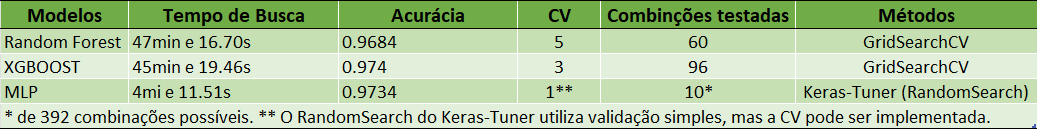

## 3.2 Treinamento com parâmetros escolhidos

### 3.2.1 Treinamento RF

In [ ]:
# Implementação do Random Forest na base MNIST

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
import time

# Treinamento utilizando os parâmetros encontrados no GridSearchCV

classificador_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth= None,
    min_samples_split= 2,
    min_samples_leaf= 1,
    max_features= 'sqrt',
    bootstrap= True,
    random_state=42
    )

tempo_inicial = time.time()
classificador_rf.fit(X_train, y_train) # Dados já escalonados
tempo_treinamento_rf = time.time() - tempo_inicial
print(f'Tempo de treinamento do Random Forest: {tempo_treinamento_rf:.2f} segundos')

# Predição

tempo_inicial = time.time()
y_pred_rf = classificador_rf.predict(X_test)
tempo_predicao_rf = time.time() - tempo_inicial
print(f'Tempo de predição do Random Forest: {tempo_predicao_rf:.2f} segundos')




Tempo de treinamento do Random Forest: 73.19 segundos
Tempo de predição do Random Forest: 0.85 segundos


### 3.2.2 Treinamento XGBOOST

In [ ]:
# Implementação do XGBOOST na base MNIST

from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report
import time

# Treinamento utilizando os parâmetros encontrados no GridSearchCV

classificador_xgb = XGBClassifier(
    n_estimators=200,
    max_depth= 7,
    learning_rate= 0.1,
    subsample= 0.9,
    colsample_bytree= 0.7,
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
    )

# converte y para inteiro
y_train_int_xgb = y_train.astype(int)
y_test_int_xgb = y_test.astype(int)

tempo_inicial = time.time()
classificador_xgb.fit(X_train, y_train_int_xgb) # Dados já escalonados
tempo_treinamento_xgb = time.time() - tempo_inicial
print(f'Tempo de treinamento do XGBOOST: {tempo_treinamento_xgb:.2f} segundos')

# Predição

tempo_inicial = time.time()
y_pred_xgb = classificador_xgb.predict(X_test)
tempo_predicao_xgb = time.time() - tempo_inicial
print(f'Tempo de predição do XGBOOST: {tempo_predicao_xgb:.2f} segundos')


/usr/local/lib/python3.13/dist-packages/xgboost/training.py:200: UserWarning: [20:37:42] WARNING: /__w/xgboost/xgboost/src/learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Tempo de treinamento do XGBOOST: 668.69 segundos
Tempo de predição do XGBOOST: 0.80 segundos


### 3.2.3 Treinamento MLP

In [ ]:
# Implementação do Multilayer Perceptron na base MNIST
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input # Import Input layer
from tensorflow.keras.utils import to_categorical
import time

# Convert y_train and y_test to integers if they are not already
# (This step is important for sparse_categorical_cross
y_train_int = y_train.astype(int)
y_test_int = y_test.astype(int)

# Convert labels to one-hot encoding
y_train_one_hot = to_categorical(y_train_int, num_classes=10)
y_test_one_hot = to_categorical(y_test_int, num_classes=10)

# Definindo a arquitetura do modelo com um Input layer explícito
model = Sequential()
model.add(Input(shape=(X_train.shape[1],))) # Explicit Input layer
model.add(Dense(128, activation='relu')) # No input_shape here
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# Compilando o modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# treinando o modelo
tempo_inicial = time.time()
model.fit(X_train, y_train_one_hot, epochs=50, batch_size=32, validation_split=0.2, verbose=0)
tempo_treinamento_mlp = time.time() - tempo_inicial
print(f'Tempo de treinamento do MLP: {tempo_treinamento_mlp:.2f} segundos')

# predição
tempo_inicial = time.time()
y_pred_mlp = model.predict(X_test)
tempo_predicao_mlp = time.time() - tempo_inicial
print(f'Tempo de predição do MLP: {tempo_predicao_mlp:.2f} segundos')

Tempo de treinamento do MLP: 239.79 segundos
438/438 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Tempo de predição do MLP: 1.46 segundos


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,160 (1.25 MB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 218,774 (854.59 KB)

In [ ]:
# 1. Salva o modelo
model.save('modelo_mlp.keras')

# 2. Força a verificação se o arquivo realmente existe no sistema do Colab
import os
if os.path.exists('modelo_mlp.keras'):
    print("O arquivo foi gerado com sucesso no servidor do Colab!")
else:
    print("Erro: O arquivo não foi encontrado no sistema de arquivos.")

# 3. Faz o download automático para a sua máquina (ignora a aba lateral)
from google.colab import files
files.download('modelo_mlp.keras')


O arquivo foi gerado com sucesso no servidor do Colab!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

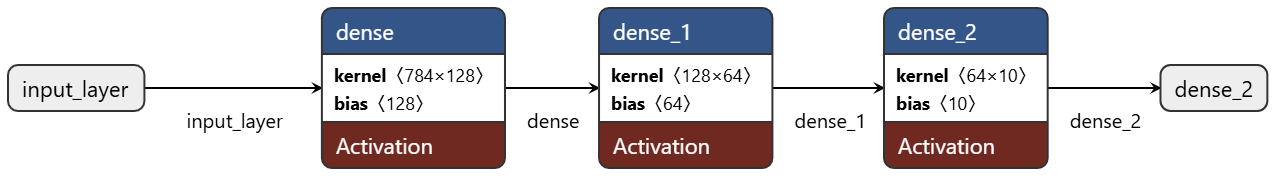![modelo_mlp.keras.png]()

# Fase 4. Avaliação Comparativa de Desempenho

## 4.1 Matriz de Confusão dos Modelos

### 4.1.1 Matriz de Confusão RF

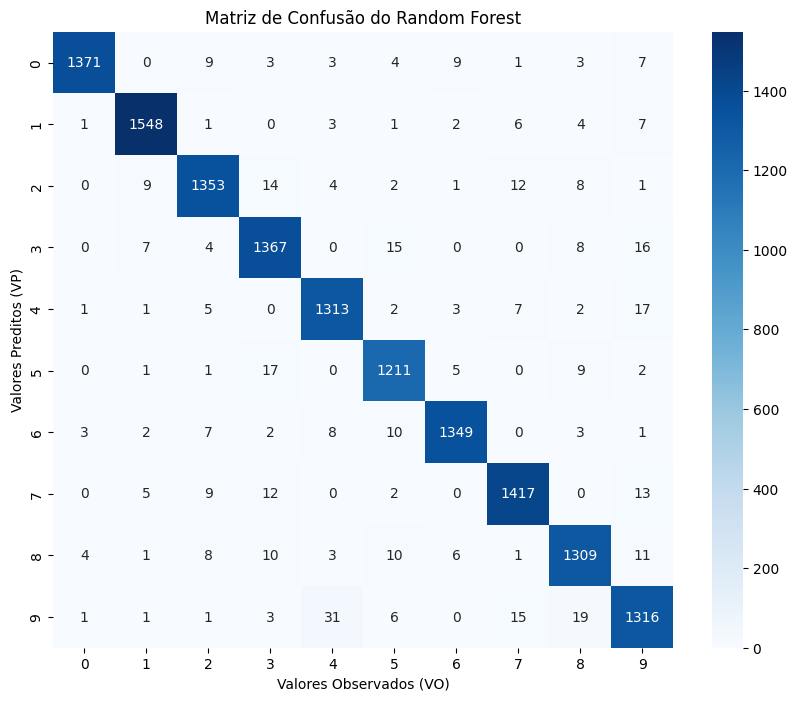

In [ ]:
# Matriz de confusão completa (10x10) com mapa de Calor (Heatmap) do Random Forest
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusão 10x10 com mapa de calor
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 8))
plt.title('Matriz de Confusão do Random Forest')
# Plotting cm.T to have True Values on X-axis and Predicted Values on Y-axis
sns.heatmap(cm_rf.T, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_pred_rf))
plt.xlabel('Valores Observados (VO)')
plt.ylabel('Valores Preditos (VP)')
plt.show()

### 4.1.2 Matriz Confusão XGBOOST

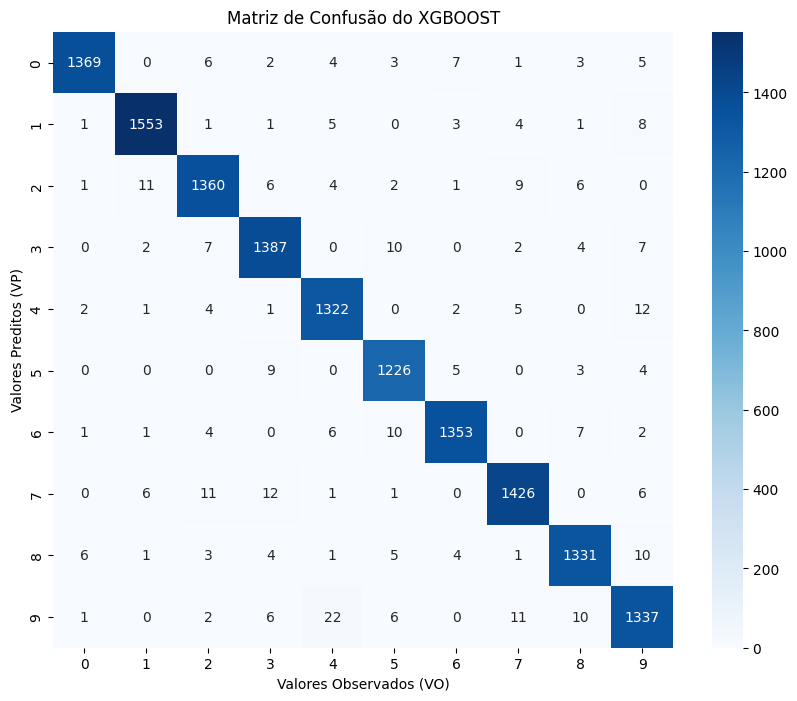

In [ ]:
# Matriz de confusão completa (10x10) com mapa de Calor (Heatmap) do XGBOOST
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusão 10x10 com mapa de calor
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(10, 8))
plt.title('Matriz de Confusão do XGBOOST')
# Plotting cm.T to have True Values on X-axis and Predicted Values on Y-axis
sns.heatmap(cm.T, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_pred_xgb))
plt.xlabel('Valores Observados (VO)')
plt.ylabel('Valores Preditos (VP)')
plt.show()


### 4.1.3 Matriz de Confusão do MLP

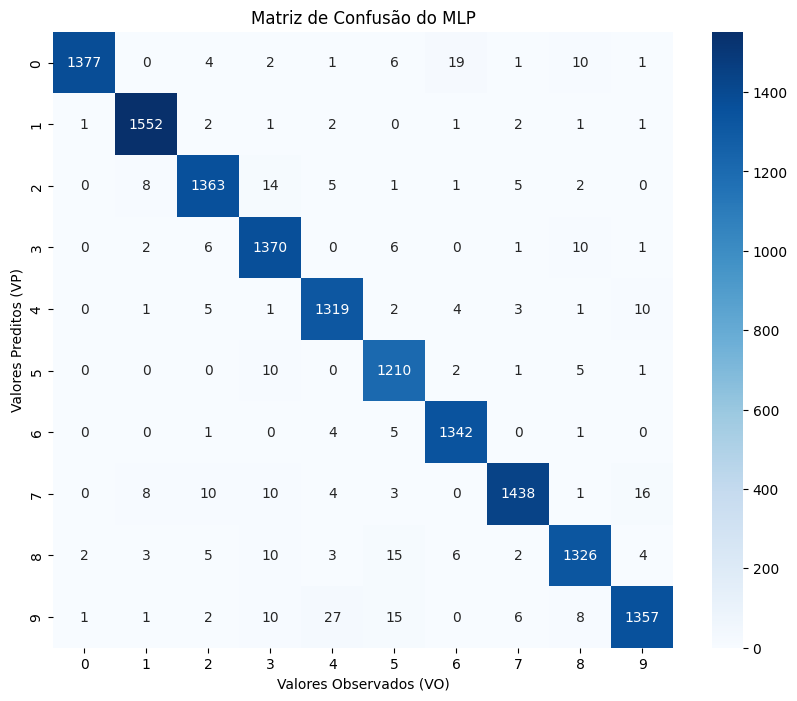

In [ ]:
# Matriz de confusão completa (10x10) com mapa de Calor (Heatmap) do MLP
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Converter as probabilidades de y_pred_mlp para classes preditas (argmax)
y_pred_mlp_classes = np.argmax(y_pred_mlp, axis=1)

# Matriz de confusão 10x10 com mapa de calor
# Usar y_test_int (inteiros) para os valores verdadeiros e as classes preditas para o MLP
cm_mlp = confusion_matrix(y_test_int, y_pred_mlp_classes)
plt.figure(figsize=(10, 8))
plt.title('Matriz de Confusão do MLP')
# Plotting cm_mlp.T to have True Values on X-axis and Predicted Values on Y-axis
# Usar np.unique(y_test_int) para os rótulos dos eixos
sns.heatmap(cm_mlp.T, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test_int), yticklabels=np.unique(y_pred_mlp_classes))
plt.xlabel('Valores Observados (VO)')
plt.ylabel('Valores Preditos (VP)')
plt.show()


## 4.2 Maiores taxas de confusão

### 4.2.1 Maiores Taxas RF


Maiores taxas de confusão (contagem > 10):
[VO: 3 - VP: 2] -> Total: 14
[VO: 3 - VP: 5] -> Total: 17
[VO: 3 - VP: 7] -> Total: 12
[VO: 4 - VP: 9] -> Total: 31
[VO: 5 - VP: 3] -> Total: 15
[VO: 7 - VP: 2] -> Total: 12
[VO: 7 - VP: 9] -> Total: 15
[VO: 8 - VP: 9] -> Total: 19
[VO: 9 - VP: 3] -> Total: 16
[VO: 9 - VP: 4] -> Total: 17
[VO: 9 - VP: 7] -> Total: 13
[VO: 9 - VP: 8] -> Total: 11


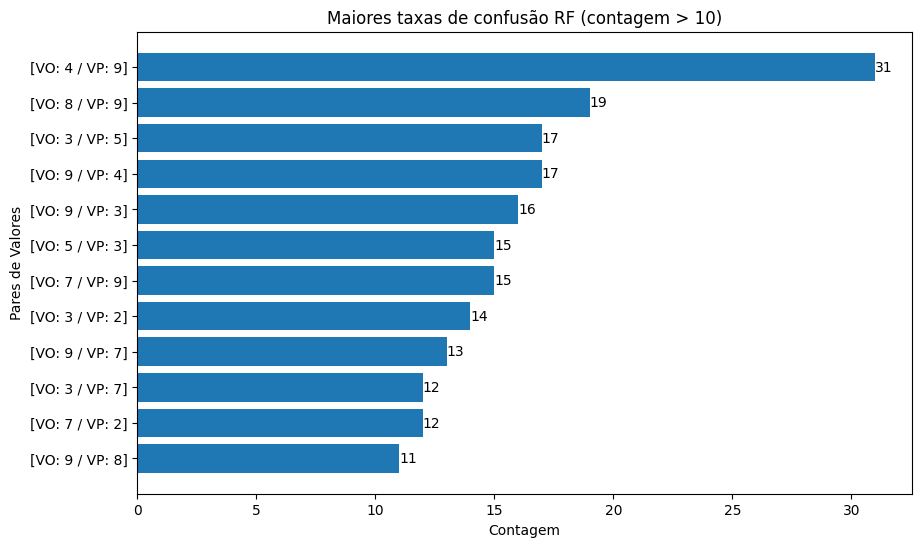

In [ ]:
# Encontrar pares de valores com confusão maior que 10
confused_pairs = []
# Iterate over the original confusion matrix 'cm' as the interpretation for confusion count is usually cm[true, predicted]
for i in range(cm_rf.shape[0]): # True classes
    for j in range(cm_rf.shape[1]): # Predicted classes
        if i != j and cm_rf[i, j] > 10:
            confused_pairs.append((f'[VO: {np.unique(y_test)[i]}', f'VP: {np.unique(y_pred_rf)[j]}]', cm_rf[i, j]))

if confused_pairs:
    print('\nMaiores taxas de confusão (contagem > 10):')
    for true_val, pred_val, count in confused_pairs:
        print(f'{true_val} - {pred_val} -> Total: {count}')
else:
    print('\nNão há pares com confusão maior que 10.')


# Gráfico ordenado da contagem do maior para o menor par da matriz de confusão


# 1. Ordena a lista pelo 'count' (terceiro elemento) em ordem decrescente
confused_pairs_sorted = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

# 2. Configuração do gráfico
plt.figure(figsize=(10, 6))

# Extração dos dados ordenados para facilitar o código
counts = [count for _, _, count in confused_pairs_sorted]
labels = [f"{true_val} / {pred_val}" for true_val, pred_val, _ in confused_pairs_sorted]

# Plota as barras horizontais
plt.barh(range(len(confused_pairs_sorted)), counts, tick_label=labels)

plt.xlabel('Contagem')
plt.ylabel('Pares de Valores')
plt.title('Maiores taxas de confusão RF (contagem > 10)')

# Inverte o eixo Y para que a maior barra (index 0) fique no topo
plt.gca().invert_yaxis()

# Rótulos dos dados da contagem ao lado de cada barra
for i, count in enumerate(counts):
    plt.text(count, i, str(count), ha='left', va='center')

plt.show()

### 4.2.2 Maiores Taxas XGBOOST


Maiores taxas de confusão (contagem > 10):
[VO: 1 - VP: 2] -> Total: 11
[VO: 2 - VP: 7] -> Total: 11
[VO: 3 - VP: 7] -> Total: 12
[VO: 4 - VP: 9] -> Total: 22
[VO: 7 - VP: 9] -> Total: 11
[VO: 9 - VP: 4] -> Total: 12


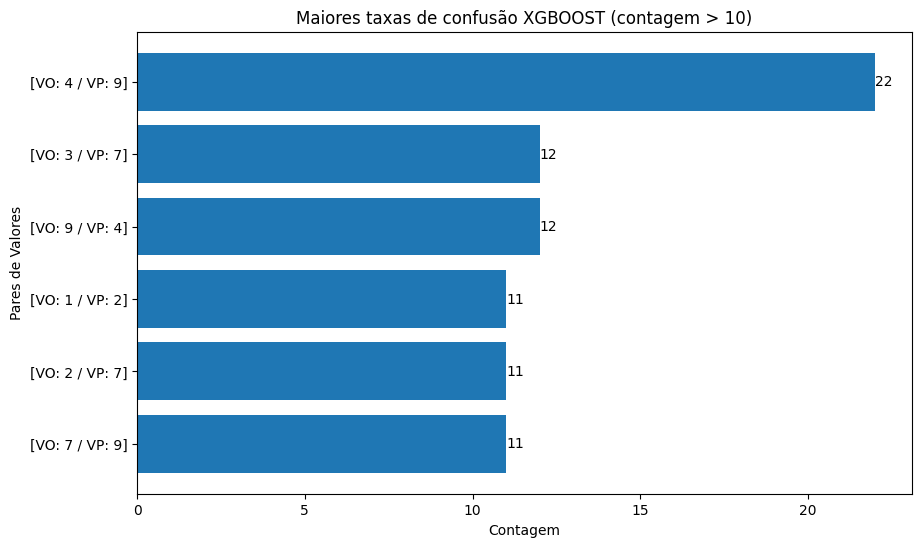

In [ ]:
# Encontrar pares de valores com confusão maior que 10
confused_pairs = []
# Iterate over the original confusion matrix 'cm' as the interpretation for confusion count is usually cm[true, predicted]
for i in range(cm_xgb.shape[0]): # True classes
    for j in range(cm_xgb.shape[1]): # Predicted classes
        if i != j and cm[i, j] > 10:
            confused_pairs.append((f'[VO: {np.unique(y_test)[i]}', f'VP: {np.unique(y_pred_xgb)[j]}]', cm_xgb[i, j]))

if confused_pairs:
    print('\nMaiores taxas de confusão (contagem > 10):')
    for true_val, pred_val, count in confused_pairs:
        print(f'{true_val} - {pred_val} -> Total: {count}')
else:
    print('\nNão há pares com confusão maior que 10.')


# Gráfico ordenado da contagem do maior para o menor par da matriz de confusão


# 1. Ordena a lista pelo 'count' (terceiro elemento) em ordem decrescente
confused_pairs_sorted = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

# 2. Configuração do gráfico
plt.figure(figsize=(10, 6))

# Extração dos dados ordenados para facilitar o código
counts = [count for _, _, count in confused_pairs_sorted]
labels = [f"{true_val} / {pred_val}" for true_val, pred_val, _ in confused_pairs_sorted]

# Plota as barras horizontais
plt.barh(range(len(confused_pairs_sorted)), counts, tick_label=labels)

plt.xlabel('Contagem')
plt.ylabel('Pares de Valores')
plt.title('Maiores taxas de confusão XGBOOST (contagem > 10)')

# Inverte o eixo Y para que a maior barra (index 0) fique no topo
plt.gca().invert_yaxis()

# Rótulos dos dados da contagem ao lado de cada barra
for i, count in enumerate(counts):
    plt.text(count, i, str(count), ha='left', va='center')

plt.show()

### 4.2.3 Maiores das do MLP


Maiores taxas de confusão (contagem > 10):
[VO: 3 - VP: 2] -> Total: 14
[VO: 4 - VP: 9] -> Total: 27
[VO: 5 - VP: 8] -> Total: 15
[VO: 5 - VP: 9] -> Total: 15
[VO: 6 - VP: 0] -> Total: 19
[VO: 9 - VP: 7] -> Total: 16


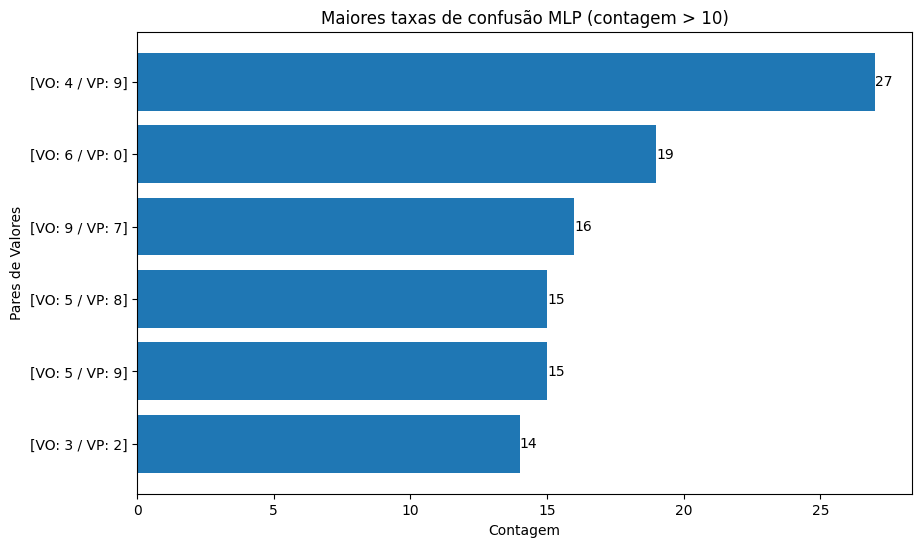

In [ ]:
# Encontrar pares de valores com confusão maior que 10 do MLP
confused_pairs = []
# Iterate over the original confusion matrix 'cm' as the interpretation for confusion count is usually cm[true, predicted]
for i in range(cm_mlp.shape[0]): # True classes
    for j in range(cm_mlp.shape[1]): # Predicted classes
        if i != j and cm_mlp[i, j] > 10:
            confused_pairs.append((f'[VO: {np.unique(y_test_int)[i]}', f'VP: {np.unique(y_pred_mlp_classes)[j]}]', cm_mlp[i, j]))

if confused_pairs:
    print('\nMaiores taxas de confusão (contagem > 10):')
    for true_val, pred_val, count in confused_pairs:
        print(f'{true_val} - {pred_val} -> Total: {count}')
else:
    print('\nNão há pares com confusão maior que 10.')

# Gráfico ordenado da contagem do maior para o menor par da matriz de confusão do MLP

# Ordena a lista pelo count
confused_pairs_sorted = sorted(confused_pairs, key=lambda x: x[2], reverse=True)

# Configuração do gráfico
plt.figure(figsize=(10, 6))

# Extração dos dados ordenados para facilitar o código
counts = [count for _, _, count in confused_pairs_sorted]
labels = [f"{true_val} / {pred_val}" for true_val, pred_val, _ in confused_pairs_sorted]

# Plota as barras horizontais
plt.barh(range(len(confused_pairs_sorted)), counts, tick_label=labels)

plt.xlabel('Contagem')
plt.ylabel('Pares de Valores')
plt.title('Maiores taxas de confusão MLP (contagem > 10)')

# Inverte o eixo Y para que a maior barra (index 0) fique no topo
plt.gca().invert_yaxis()

# Rótulos dos dados da contagem ao lado de cada barra
for i, count in enumerate(counts):
    plt.text(count, i, str(count), ha='left', va='center')

plt.show()


## 4.3 Métricas dos Modelos

### 4.3.1 Métricas Random Forest

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1381
           1       0.98      0.98      0.98      1575
           2       0.96      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           4       0.97      0.96      0.97      1365
           5       0.97      0.96      0.97      1263
           6       0.97      0.98      0.98      1375
           7       0.97      0.97      0.97      1459
           8       0.96      0.96      0.96      1365
           9       0.94      0.95      0.95      1391

    accuracy                           0.97     14000
   macro avg       0.97      0.97      0.97     14000
weighted avg       0.97      0.97      0.97     14000



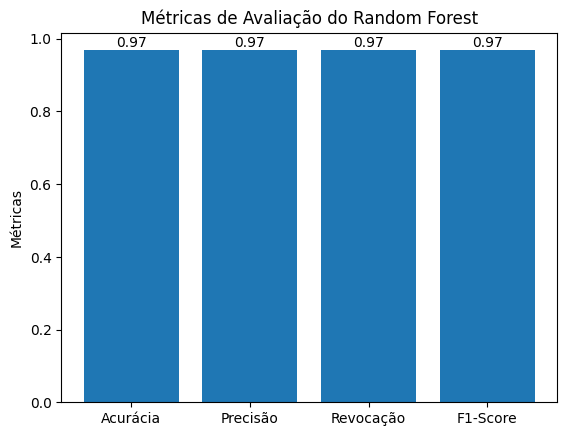

In [ ]:
# Métrias do Random Forest utilizando Classification Report
# Acurácia Global (Accuracy)
# Precisão Média Ponderada (Precision)
# Revocação/Sensibilidade Média Ponderada (Recall)
# F1-Score Ponderado (F1-Score)

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Gerar o relatório de classificação
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)

# Relatório de métricas de cada dígito
print("Relatório de Classificação:")
print(classification_report(y_test, y_pred_rf))

# Extrair as métricas
accuracy = report_rf['accuracy']
weighted_avg = report_rf['weighted avg']
precision = weighted_avg['precision']
recall = weighted_avg['recall']
f1_score = weighted_avg['f1-score']

# Criar um gráfico de barras
labels = ['Acurácia', 'Precisão', 'Revocação', 'F1-Score']
values = [accuracy, precision, recall, f1_score]
plt.bar(labels, values)
# Rótulos em cima das barras
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.ylabel('Métricas')
plt.title('Métricas de Avaliação do Random Forest')
plt.show()


### 4.3.2 Métricas XGBOOST

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1381
           1       0.98      0.99      0.99      1575
           2       0.97      0.97      0.97      1398
           3       0.98      0.97      0.97      1428
           4       0.98      0.97      0.97      1365
           5       0.98      0.97      0.98      1263
           6       0.98      0.98      0.98      1375
           7       0.97      0.98      0.98      1459
           8       0.97      0.98      0.97      1365
           9       0.96      0.96      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.98      0.98     14000
weighted avg       0.98      0.98      0.98     14000



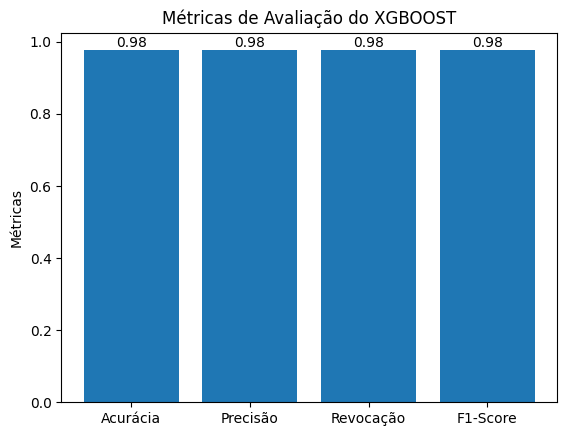

In [ ]:
# Métrias do XGBOOST utilizando Classification Report
# Acurácia Global (Accuracy)
# Precisão Média Ponderada (Precision)
# Revocação/Sensibilidade Média Ponderada (Recall)
# F1-Score Ponderado (F1-Score)

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Gerar o relatório de classificação
report_xgb = classification_report(y_test_int, y_pred_xgb, output_dict=True)

# Relatório de Métricas de cada dígito
print("Relatório de Classificação:")
print(classification_report(y_test_int, y_pred_xgb))

# Extrair as métricas
accuracy = report_xgb['accuracy']
weighted_avg = report_xgb['weighted avg']
precision = weighted_avg['precision']
recall = weighted_avg['recall']
f1_score = weighted_avg['f1-score']

# Criar gráfico de barras
labels = ['Acurácia', 'Precisão', 'Revocação', 'F1-Score']
values = [accuracy, precision, recall, f1_score]
plt.bar(labels, values)
# Rótulo em cima das barras
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.ylabel('Métricas')
plt.title('Métricas de Avaliação do XGBOOST')
plt.show()

### 4.3.3 Métricas MLP

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1381
           1       0.99      0.99      0.99      1575
           2       0.97      0.97      0.97      1398
           3       0.98      0.96      0.97      1428
           4       0.98      0.97      0.97      1365
           5       0.98      0.96      0.97      1263
           6       0.99      0.98      0.98      1375
           7       0.97      0.99      0.98      1459
           8       0.96      0.97      0.97      1365
           9       0.95      0.98      0.96      1391

    accuracy                           0.98     14000
   macro avg       0.98      0.97      0.98     14000
weighted avg       0.98      0.98      0.98     14000



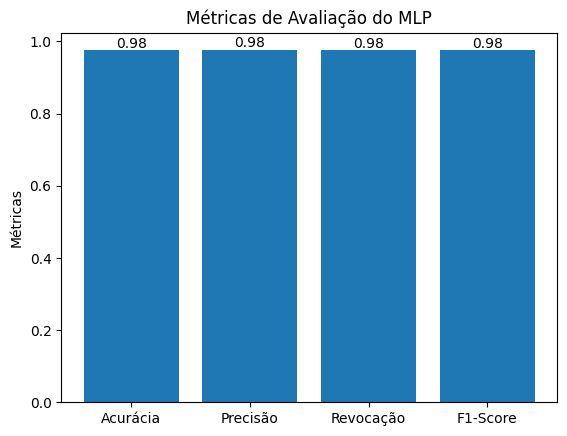

In [ ]:
# Métrias do MLP utilizando Classification Report
# Acurácia Global (Accuracy)
# Precisão Média Ponderada (Precision)
# Revocação/Sensibilidade Média Ponderada (Recall)
# F1-Score Ponderado (F1-Score)

import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

# Gerar o relatório de classificação
report_mlp = classification_report(y_test_int, y_pred_mlp_classes, output_dict=True)

#
print("Relatório de Classificação:")
print(classification_report(y_test_int, y_pred_mlp_classes))

# Extrair as métricas
accuracy = report_mlp['accuracy']
weighted_avg = report_mlp['weighted avg']
precision = weighted_avg['precision']
recall = weighted_avg['recall']
f1_score = weighted_avg['f1-score']

# Criar um gráfico de barras
labels = ['Acurácia', 'Precisão', 'Revocação', 'F1-Score']
values = [accuracy, precision, recall, f1_score]
plt.bar(labels, values)
# Rótulos em cima das barras
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 2)), ha='center', va='bottom')

plt.ylabel('Métricas')
plt.title('Métricas de Avaliação do MLP')
plt.show()

### 4.3.4 Conclusão Técnica

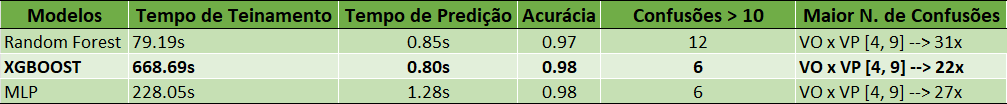

Conclusão: Todos os modelos avaliados neste projeto apresentaram desempenho (Acurácia) semelhantes em suas etapas de treinamento e teste, sendo que o modelo **Random Forest** foi o que apresentou o menor trempo de treinamento (79.19s) e o XGBOOST foi o que levou mais tempo (668.69s). Quando comparamos as matrizes de confusão vemos que os modelos que todos eles apresentaram algum graua de confusão, sendo que optou-se por mostrar as mais evidentes (contagens maiores ou iguais a 10, sou seja, a quantidade comparações entre Valores Obsrvados e Preditos errôneos), sendo que o Random Forest evidenciou 12 parece de comparações erradas, seguido pelos XBOOST e o MLP que apresentaram extamente a mentade de pares confundidos. Em todos os modelos o principal par confundido foi na comparação entre os dígitos 4 e 9, sendo que no Random Forest essa confusão ocorreu 31 vezes (considerando todas as confusões), e 27 vezes essa confusão ocorreu com o  MLP.

Desta forma concluímos que o maior custo computacional foi do modelo XBOOST, sendo também o modelo com a melhor performance (menores taxas de confusão, acurácia de 0.98

## 4.4 Tabela Consolidada e Modelo Campeão

In [ ]:
# Tabela consolidada com as métricas dos 3 modelos
import pandas as pd

# Extrair métricas para Random Forest
rf_accuracy = report_rf['accuracy']
rf_precision = report_rf['weighted avg']['precision']
rf_recall = report_rf['weighted avg']['recall']
rf_f1_score = report_rf['weighted avg']['f1-score']

# Extrair métricas para XGBoost
xgb_accuracy = report_xgb['accuracy']
xgb_precision = report_xgb['weighted avg']['precision']
xgb_recall = report_xgb['weighted avg']['recall']
xgb_f1_score = report_xgb['weighted avg']['f1-score']

# Extrair métricas para MLP
mlp_accuracy = report_mlp['accuracy']
mlp_precision = report_mlp['weighted avg']['precision']
mlp_recall = report_mlp['weighted avg']['recall']
mlp_f1_score = report_mlp['weighted avg']['f1-score']

# Criar um DataFrame para consolidar as métricas
metrics_data = {
    'Modelo': ['Random Forest', 'XGBoost', 'MLP'],
    'Acurácia': [rf_accuracy, xgb_accuracy, mlp_accuracy],
    'Precisão (Weighted Avg)': [rf_precision, xgb_precision, mlp_precision],
    'Recall (Weighted Avg)': [rf_recall, xgb_recall, mlp_recall],
    'F1-Score (Weighted Avg)': [rf_f1_score, xgb_f1_score, mlp_f1_score]
}

metrics_df = pd.DataFrame(metrics_data)

# Exibir a tabela consolidada
print("Tabela Consolidada de Métricas dos Modelos:")
print(metrics_df.round(4))

# Opcional: Identificar o modelo campeão com base na acurácia
best_model_row = metrics_df.loc[metrics_df['Acurácia'].idxmax()]
print(f"\nModelo Campeão (baseado na Acurácia): {best_model_row['Modelo']} com Acurácia de {best_model_row['Acurácia']:.4f}")

Tabela Consolidada de Métricas dos Modelos:
          Modelo  Acurácia  Precisão (Weighted Avg)  Recall (Weighted Avg)  \
0  Random Forest    0.9681                   0.9681                 0.9681   
1        XGBoost    0.9760                   0.9760                 0.9760   
2            MLP    0.9753                   0.9755                 0.9753   

   F1-Score (Weighted Avg)  
0                   0.9681  
1                   0.9760  
2                   0.9753  

Modelo Campeão (baseado na Acurácia): XGBoost com Acurácia de 0.9760


# Fase 5. Desafio (cenários fora do padrão).

obs: Se quiser testar com imagens manuscritas diretamente, pule para a fase 5.3

## Fase 5.1 - Desafio (A) Treinamento Restrito com Classes Ocultadas (Class Masking)

### a) Selecionar ao menos duas classes para serem totalmente removidas da base de treinamento (por exemplo: ocultar os dígitos 4 e 7). Treinar um dos modelos (clássico ou rede neural) sem nunca ter visto esses dois dígitos durante o ajuste dos pesos.

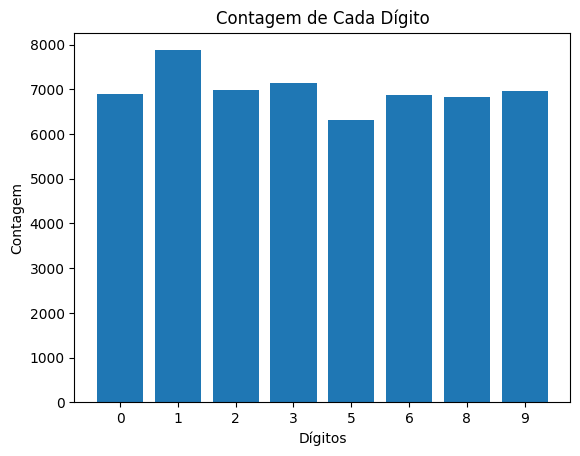

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split

# Carregando X e y sem o 4 e 7
# Criar uma máscara booleana para remover os dígitos '4' e '7' dos rótulos
mask = ~np.isin(y, ['4', '7'])

X_masked = X[mask]
y_masked = y[mask]

# Separando em treino e teste
X_train_masked, X_test_masked, y_train_masked, y_test_masked = train_test_split(X_masked, y_masked, test_size=0.2, random_state=42, stratify=y_masked)

# Normalização divindo por 255
X_train_masked = X_train_masked / 255.0
X_test_masked = X_test_masked / 255.0

# Gráfico da contagem dos dígitos
import matplotlib.pyplot as plt
import numpy as np

unique, counts = np.unique(y_masked, return_counts=True)
plt.bar(unique, counts)
plt.xlabel('Dígitos')
plt.ylabel('Contagem')
plt.title('Contagem de Cada Dígito')
plt.show()

In [ ]:
# Treinamento do Random Forest Masked
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import time

# Treinamento
classificador_rf_masked = RandomForestClassifier(
    n_estimators=200,
    max_depth= None,
    min_samples_split= 2,
    min_samples_leaf= 1,
    max_features= 'sqrt',
    bootstrap= True,
    random_state=42
    )

tempo_inicial = time.time()
classificador_rf_masked.fit(X_train_masked, y_train_masked) # Dados já escalonados
tempo_treinamento_rf = time.time() - tempo_inicial
print(f'Tempo de treinamento do Random Forest: {tempo_treinamento_rf:.2f} segundos')

# Predição

tempo_inicial = time.time()
y_pred_rf_masked = classificador_rf_masked.predict(X_test_masked)
tempo_predicao_rf_masked = time.time() - tempo_inicial
print(f'Tempo de predição do Random Forest: {tempo_predicao_rf_masked:.2f} segundos')

# métricas de avaliação do treinamento
print(classification_report(y_test_masked, y_pred_rf_masked))

Tempo de treinamento do Random Forest: 64.58 segundos
Tempo de predição do Random Forest: 0.66 segundos
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1381
           1       0.99      0.99      0.99      1575
           2       0.97      0.97      0.97      1398
           3       0.96      0.96      0.96      1428
           5       0.97      0.96      0.97      1263
           6       0.98      0.98      0.98      1375
           8       0.96      0.96      0.96      1365
           9       0.98      0.98      0.98      1392

    accuracy                           0.97     11177
   macro avg       0.97      0.97      0.97     11177
weighted avg       0.97      0.97      0.97     11177



## Fase 5.2 - Desafio (B) Teste de Generalização Extrema (Inferência OOD)

### b) Submeter o modelo treinado no Desafio A a um conjunto de teste contendo exclusivamente as classes que foram ocultadas (no exemplo: apenas imagens dos dígitos 4 e 7).

In [ ]:
# Manter no dataset de teste somente os dígitos 4 e 7, removendo os outros
# Criar uma máscara booleana para manter apenas os dígitos '4' e '7' nos rótulos
mask_test = np.isin(y_test, ['4', '7'])

X_test_masked = X_test[mask_test]
y_test_masked = y_test[mask_test]

# Verificação (impressão) dos dígitos que estão na base de teste X_test_masked
print("Digitos a serem testados no classificador RF: ", np.unique(y_test_masked))

# Normalização divindo por 255
X_test_masked = X_test_masked / 255.0

# Aplicação do Random Forest com máscara (treinado sem o 4 e 7) para ser testado numa base com o 4 e 7
tempo_inicial = time.time()
y_pred_rf_masked_test = classificador_rf_masked.predict(X_test_masked)
tempo_predicao_rf_masked_test = time.time() - tempo_inicial
print(f'Tempo de predição do Random Forest com máscara: {tempo_predicao_rf_masked_test:.2f} segundos')

# Métricas de avaliação da predição da inferência OOD
print(classification_report(y_test_masked, y_pred_rf_masked_test))

Digitos a serem testados no classificador RF:  ['4' '7']
Tempo de predição do Random Forest com máscara: 0.13 segundos
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       0.0
           1       0.00      0.00      0.00       0.0
           2       0.00      0.00      0.00       0.0
           3       0.00      0.00      0.00       0.0
           4       0.00      0.00      0.00    1365.0
           5       0.00      0.00      0.00       0.0
           6       0.00      0.00      0.00       0.0
           7       0.00      0.00      0.00    1459.0
           8       0.00      0.00      0.00       0.0
           9       0.00      0.00      0.00       0.0

    accuracy                           0.00    2824.0
   macro avg       0.00      0.00      0.00    2824.0
weighted avg       0.00      0.00      0.00    2824.0



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_

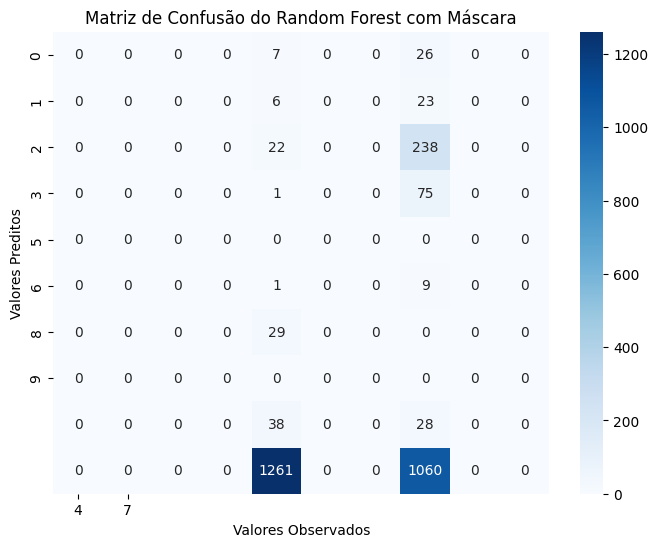

In [ ]:
# heat map da matriz de confusão da máscara (OOD)
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calcular a matriz de confusão

cm_rf_masked = confusion_matrix(y_test_masked, y_pred_rf_masked_test)

# Plotar a matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf_masked.T, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_test_masked), yticklabels=np.unique(y_pred_rf_masked_test))
plt.xlabel('Valores Observados')
plt.ylabel('Valores Preditos')
plt.title('Matriz de Confusão do Random Forest com Máscara')
plt.show()

In [ ]:
# Conta os dígitos 4 e 7 da base de teste do OOD
print(f'Quantidade de dígitos 4 na base de teste do OOD: {np.sum(y_test_masked == "4")}')
print(f'Quantidade de dígitos 7 na base de teste do OOD: {np.sum(y_test_masked == "7")}')

Quantidade de dígitos 4 na base de teste do OOD: 1365
Quantidade de dígitos 7 na base de teste do OOD: 1459


Análise do Comportamento:

Quando eliminamos do treinamento os dígitos 4 e 7 e usamos justamente o 4 e o 7 para teste ocorre um caso clássico de Open-Set Recognition (OSR) e dados totalmente Out-of-Distribution (OOD) no teste: o espaço de rótulos de treino $Y_{\text{treino}} = \{0, 1, 2, 3, 5, 6, 8, 9\}$ é completamente disjunto do conjunto de teste $Y_{\text{teste}} = \{4, 7\}$.

- Há um desconfiguração de todas as métricas do relatório de classificação, ou seja, ficam zeradas.
- O modelo nunca preverá (ou não deveria prever) o 4 e o 7, pois não conhece esses valores. A diagonal prencipal da matriz de confusão fica zerada.
- É interessante observar que os valores em destaque que aparecem na matriza são referentes ao quantitativos de valores de 4 e 7 que deveriam ser previstos, mas não são, pois não existem (1261 e 1060) respectivamente, sendo que os outros valores são os restantes para completar o somatório de cada valor de 4 e 7, distribuidos em outras classes.
- Concluindo: matriz totalmente desconfigurada

## Fase 5.3 - Desafio (C) Inferência com Imagens Manuscritas Próprias

In [ ]:
# Monta o Google Drive para acessar as imagens de teste
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Imagens Originais:


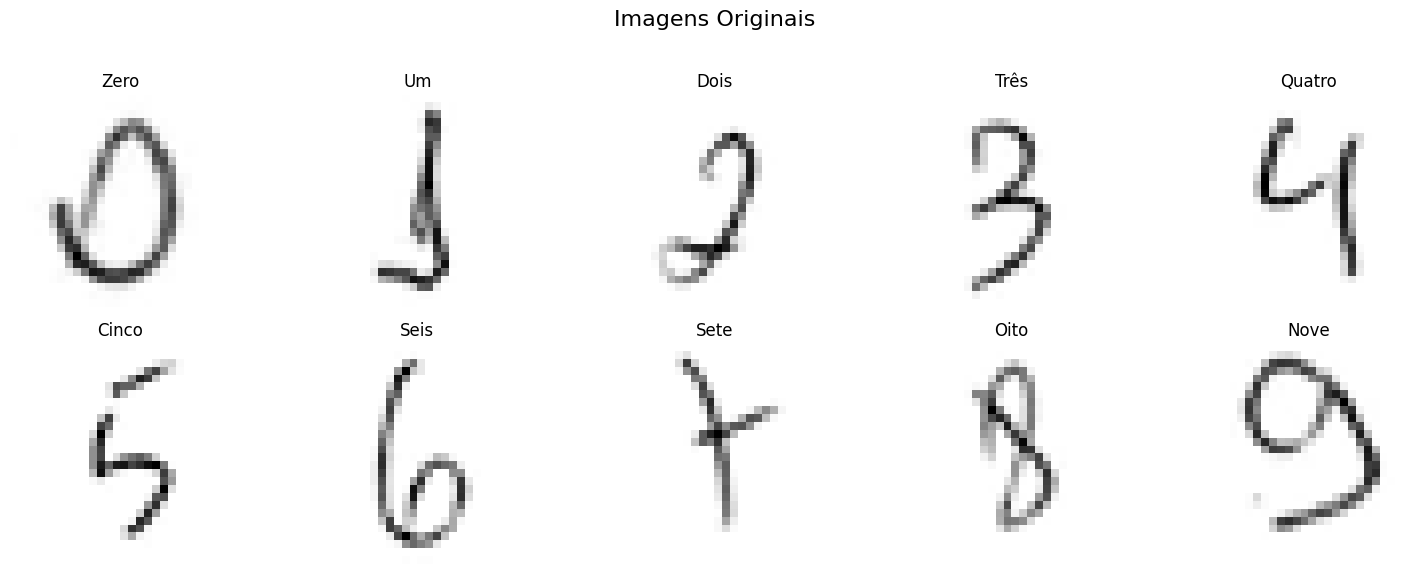


Imagens com fundo invertido:


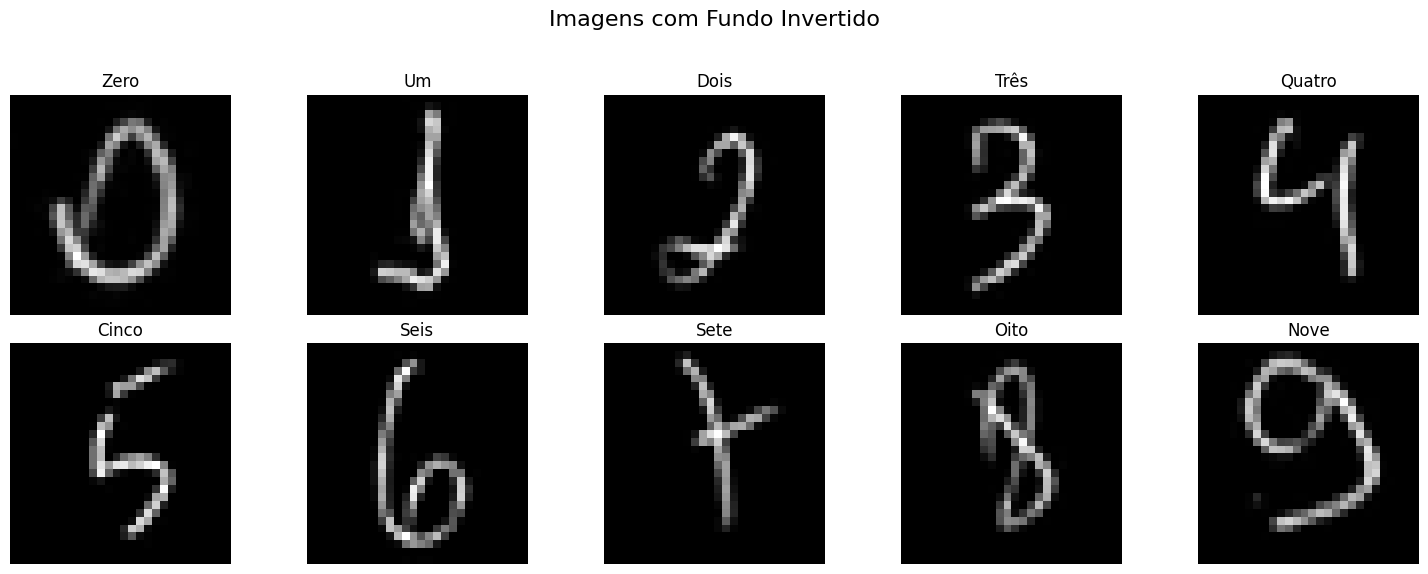

In [ ]:
# Carregamento e plotagem das imagens
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

caminho = '/content/drive/MyDrive/Curso SCTec/IA para análise preditiva 300 h/Mini-Projeto 2 - Dados'

# Lista de nomes de dígitos para carregar as imagens
digit_names = ['zero', 'um', 'dois', 'três', 'quatro', 'cinco', 'seis', 'sete', 'oito', 'nove']

original_images = []
inverted_images = []

for name in digit_names:
    # Constrói o caminho completo do arquivo
    filename = f'{caminho}/{name}_80.jpg'

    # Abre a imagem e já converte em escala de cinza
    img = Image.open(filename).convert('L')

    # Redimensiona a imagem para a resolução de 28x28 pixels
    img = img.resize((28, 28))

    # Converte a imagem em um array NumPy
    img_array = np.array(img)

    # Armazena a imagem original
    original_images.append(img_array)

    # Inverte os canais para modificar o fundo
    inverted_img_array = 255 - img_array
    inverted_images.append(inverted_img_array)

# Mostra as imagens carregadas (originais)
print('Imagens Originais:')
fig_orig, axes_orig = plt.subplots(2, 5, figsize=(15, 6))
axes_orig = axes_orig.flatten() # Achata a matriz dos eixos para facilitar a iteração

for i, img_array in enumerate(original_images):
    axes_orig[i].imshow(img_array, cmap='gray')
    axes_orig[i].set_title(digit_names[i].capitalize())
    axes_orig[i].axis('off') # Esconde os ticks dos eixos

plt.suptitle('Imagens Originais', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta o layout para evitar sobreposição
plt.show()

# Mostra as imagens com fundo alterado (invertidas)
print('\nImagens com fundo invertido:')
fig_inv, axes_inv = plt.subplots(2, 5, figsize=(15, 6))
axes_inv = axes_inv.flatten()

for i, img_array in enumerate(inverted_images):
    axes_inv[i].imshow(img_array, cmap='gray')
    axes_inv[i].set_title(digit_names[i].capitalize())
    axes_inv[i].axis('off')

plt.suptitle('Imagens com Fundo Invertido', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

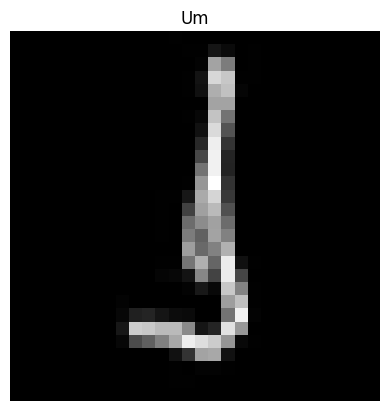

In [ ]:
# mostra uma das imagens já invertidas
plt.imshow(inverted_images[1], cmap='gray')
plt.title(digit_names[1].capitalize())
plt.axis('off')
plt.show()

## 5.4 Aplicando os Modelos Treinados

In [ ]:
# Aplicando os Modelos Treinados e Gerando um Quadro Comparativo

import pandas as pd
import numpy as np

print('Aplicando os modelos Random Forest, XGBoost e MLP nas imagens carregadas...')
print('=' * 80)

# Lista para armazenar os resultados comparativos
comparative_results = []

# Loop através das imagens invertidas para predição
for i, img_array in enumerate(inverted_images):
    # Preprocessa a imagem: achata para 1D e normaliza para 0-1
    reshaped_img = img_array.reshape(1, -1)
    normalized_img = reshaped_img / 255.0

    # --- Random Forest Predictions ---
    predicted_digit_rf = classificador_rf.predict(normalized_img)[0]
    probabilities_rf = classificador_rf.predict_proba(normalized_img)[0]
    # Encontra a probabilidade correspondente ao dígito previsto (assumindo classes_ em ordem)
    prob_rf_predicted = probabilities_rf[np.where(classificador_rf.classes_ == predicted_digit_rf)[0][0]]

    # --- XGBoost Predictions ---
    predicted_digit_xgb = classificador_xgb.predict(normalized_img)[0]
    probabilities_xgb = classificador_xgb.predict_proba(normalized_img)[0]
    # Encontra a probabilidade correspondente ao dígito previsto
    prob_xgb_predicted = probabilities_xgb[np.where(classificador_xgb.classes_ == predicted_digit_xgb)[0][0]]

    # --- MLP Predictions ---
    # MLP's predict retorna probabilidades diretamente. verbose=0 para suprimir a barra de progresso
    probabilities_mlp = model.predict(normalized_img, verbose=0)[0]
    predicted_digit_mlp = np.argmax(probabilities_mlp)
    prob_mlp_predicted = probabilities_mlp[predicted_digit_mlp]

    # Armazena os resultados para a imagem atual
    comparative_results.append({
        'Número Carregado': digit_names[i].capitalize(),
        'RF Previsto': predicted_digit_rf,
        'RF Prob': f'{prob_rf_predicted:.4f}',
        'XGB Previsto': predicted_digit_xgb,
        'XGB Prob': f'{prob_xgb_predicted:.4f}',
        'MLP Previsto': predicted_digit_mlp,
        'MLP Prob': f'{prob_mlp_predicted:.4f}'
    })

# Cria DataFrame a partir dos resultados
comparative_df = pd.DataFrame(comparative_results)

print('\nQuadro Resumo Comparativo dos Modelos:')
print(comparative_df)
print('\n' + '=' * 80)

Aplicando os modelos Random Forest, XGBoost e MLP nas imagens carregadas...

Quadro Resumo Comparativo dos Modelos:
  Número Carregado RF Previsto RF Prob  XGB Previsto XGB Prob  MLP Previsto  \
0             Zero           0  0.7500             0   0.9978             0   
1               Um           1  0.3200             3   0.3517             1   
2             Dois           2  0.3700             2   0.8508             2   
3             Três           3  0.4950             3   0.9557             3   
4           Quatro           4  0.3600             7   0.4236             4   
5            Cinco           5  0.3250             5   0.9058             5   
6             Seis           5  0.2750             5   0.4147             6   
7             Sete           1  0.3250             5   0.3883             3   
8             Oito           3  0.1950             3   0.6224             3   
9             Nove           5  0.2150             0   0.3526             2   

  MLP Prob  
0